In [1]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("hayaalwizrah1/gold-price-prediction-dataset-20002026")
data = pd.read_csv(os.path.join(path, 'gold_data.csv'))

Using Colab cache for faster access to the 'gold-price-prediction-dataset-20002026' dataset.


In [2]:
df = data.copy()

In [3]:
df = df.set_index("Date")

In [4]:
df.loc['2002-02-14']

,2002-02-14
Gold_Open,300.000000
Gold_High,300.500000
Gold_Low,299.399994
Gold_Close,299.700012
Gold_Volume,20.000000
DXY,118.430000
SP500,1116.479980
Oil,21.219999
VIX,21.770000
Lag1,299.399994


In [5]:
df.columns

Index(['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume',
       'DXY', 'SP500', 'Oil', 'VIX', 'Lag1', 'Lag7', 'MA7', 'MA30', 'EMA20',
       'Daily_Return', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper',
       'BB_Middle', 'BB_Lower', 'ATR', 'Target'],
      dtype='object')

In [6]:
y = df['Target']
X = df.drop(columns=['Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Volume', 'ATR', 'Target'], axis=1)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

s_train = scaler.fit_transform(X_train)
s_test = scaler.transform(X_test)

X_train = pd.DataFrame(s_train, columns = X.columns, index = X_train.index)
X_test = pd.DataFrame(s_test, columns = X.columns, index = X_test.index)

In [9]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 705269.6875 - mae: 701.7828 - val_loss: 260636.5625 - val_mae: 453.9733
Epoch 2/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 98931.2578 - mae: 240.4499 - val_loss: 83542.9297 - val_mae: 254.4332
Epoch 3/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 48604.0703 - mae: 163.8128 - val_loss: 88050.7031 - val_mae: 216.3847
Epoch 4/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 32775.2930 - mae: 134.8871 - val_loss: 91572.8828 - val_mae: 231.9125
Epoch 5/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 26307.5020 - mae: 121.1042 - val_loss: 48838.2812 - val_mae: 168.7953
Epoch 6/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 23042.1992 - mae: 113.3156 - val_loss: 56231.8516 - val_mae: 183.8420
Epoch 7/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 19727.7930 - mae: 105.8986 - val_loss: 35186.7500 - val_mae: 145.6542
Epoch 8/200
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19336.5508 - mae: 10

In [13]:
y_pred = model.predict(X_test).flatten()

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [14]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R²   :", r2)

RMSE : 61.726515004143465
MAE  : 37.89531904689312
R²   : 0.995969182558856


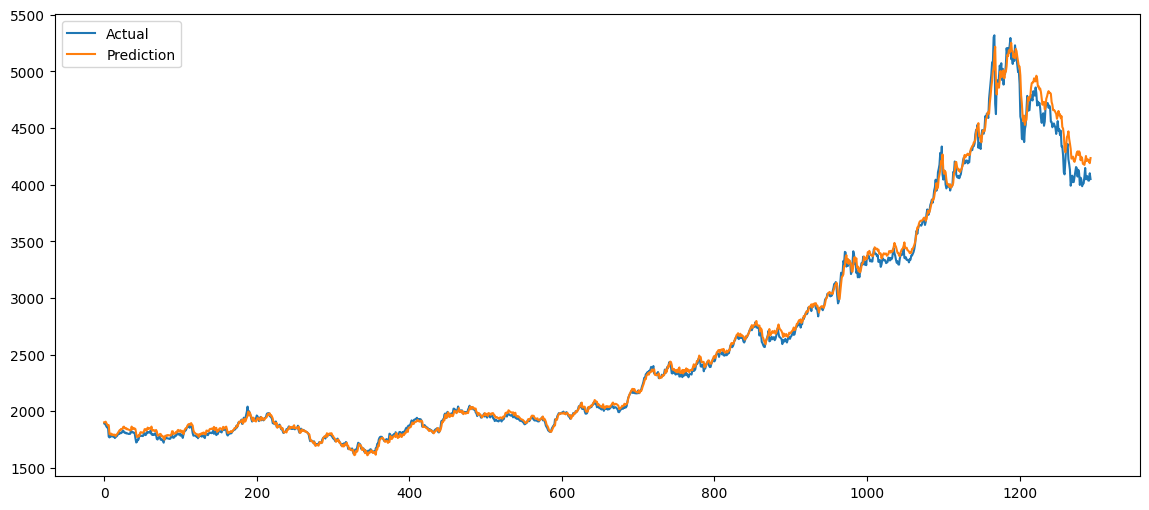

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Prediction")

plt.legend()

plt.show()

In [16]:
model.save("gold_model.keras")

In [17]:
h = df.copy()

In [19]:
!pip install -q ta

  Preparing metadata (setup.py) ... done


In [20]:
import ta

def update_features(df):

    df["Lag1"] = df["Gold_Close"].shift(1)
    df["Lag7"] = df["Gold_Close"].shift(7)

    df["MA7"] = df["Gold_Close"].rolling(7).mean()
    df["MA30"] = df["Gold_Close"].rolling(30).mean()

    df["EMA20"] = df["Gold_Close"].ewm(span=20, adjust=False).mean()

    df["Daily_Return"] = df["Gold_Close"].pct_change()

    df["RSI"] = ta.momentum.RSIIndicator(
        df["Gold_Close"],
        window=14
    ).rsi()

    macd = ta.trend.MACD(df["Gold_Close"])

    df["MACD"] = macd.macd()
    df["MACD_Signal"] = macd.macd_signal()
    df["MACD_Hist"] = macd.macd_diff()

    bb = ta.volatility.BollingerBands(df["Gold_Close"])

    df["BB_Upper"] = bb.bollinger_hband()
    df["BB_Middle"] = bb.bollinger_mavg()
    df["BB_Lower"] = bb.bollinger_lband()

    atr = ta.volatility.AverageTrueRange(
        high=df["Gold_Close"],
        low=df["Gold_Close"],
        close=df["Gold_Close"],
        window=14
    )

    df["ATR"] = atr.average_true_range()

    return df

In [21]:
import numpy as np
import pandas as pd

def forecast_30_days(model, scaler, history, features, days=30):

    history = history.copy()

    predictions = []

    future_dates = []

    for i in range(days):

        row = history.iloc[-1].copy()

        x = row[features]

        x = scaler.transform(pd.DataFrame([x]))

        pred = model.predict(x, verbose=0)[0][0]

        predictions.append(pred)

        new_row = row.copy()

        new_row["Gold_Close"] = pred

        new_date = pd.to_datetime(history.index[-1]) + pd.Timedelta(days=1)

        future_dates.append(new_date)

        history.loc[new_date] = new_row

        history = update_features(history)

    return pd.DataFrame({
        "Date": future_dates,
        "Predicted_Close": predictions
    })

In [22]:
features = X.columns.tolist()

future = forecast_30_days(
    model,
    scaler,
    h,
    features,
    days=30
)

In [23]:
future

,Date,Predicted_Close
0,2026-07-31,4234.341309
1,2026-08-01,4317.034668
2,2026-08-02,4374.499023
3,2026-08-03,4432.743652
4,2026-08-04,4488.710938
5,2026-08-05,4534.755859
6,2026-08-06,4574.191406
7,2026-08-07,4612.910156
8,2026-08-08,4649.638672
9,2026-08-09,4677.950195


In [25]:
highest = future.loc[future["Predicted_Close"].idxmax()]
lowest = future.loc[future["Predicted_Close"].idxmin()]

print(highest)
print(lowest)

Date               2026-08-12 00:00:00
Predicted_Close            4717.751953
Name: 12, dtype: object
Date               2026-07-31 00:00:00
Predicted_Close            4234.341309
Name: 0, dtype: object
